## Setup environment

In [1]:
!python -c "import monai" || pip install -q "monai-weekly[nibabel, tqdm]"
!python -c "import matplotlib" || pip install -q matplotlib
%matplotlib inline

## Setup imports

In [2]:
# Copyright 2020 MONAI Consortium
# Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
#     http://www.apache.org/licenses/LICENSE-2.0
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License.

import os
import matplotlib.pyplot as plt
import numpy as np
import shutil
import tempfile
import torch
from torch.nn import MSELoss
from monai.apps import download_url, download_and_extract
from monai.config import print_config
from monai.data import DataLoader, Dataset, CacheDataset
from monai.losses import BendingEnergyLoss, MultiScaleLoss, DiceLoss
from monai.metrics import DiceMetric
from monai.networks.blocks import Warp
from monai.networks.nets import LocalNet
from monai.transforms import (
    AddChanneld,
    Compose,
    LoadImaged,
    RandAffined,
    Resized,
    ScaleIntensityRanged,
    EnsureTyped,
)
from monai.utils import set_determinism, first

print_config()

MONAI version: 0.9.dev2212
Numpy version: 1.22.2
Pytorch version: 1.10.0+cu102
MONAI flags: HAS_EXT = False, USE_COMPILED = False
MONAI rev id: d93c76c6287099673b45957661232f054e558ca1
MONAI __file__: /opt/anaconda3/lib/python3.8/site-packages/monai/__init__.py

Optional dependencies:
Pytorch Ignite version: 0.4.8
Nibabel version: 3.2.1
scikit-image version: 0.17.2
Pillow version: 8.0.1
Tensorboard version: 2.8.0
gdown version: 4.4.0
TorchVision version: 0.8.2
tqdm version: 4.50.2
lmdb version: NOT INSTALLED or UNKNOWN VERSION.
psutil version: 5.7.2
pandas version: 1.1.3
einops version: 0.3.2
transformers version: NOT INSTALLED or UNKNOWN VERSION.
mlflow version: NOT INSTALLED or UNKNOWN VERSION.

For details about installing the optional dependencies, please visit:
    https://docs.monai.io/en/latest/installation.html#installing-the-recommended-dependencies



## Set dataset path

In [43]:
import antspynet
import ants
seg_save_path = "/zhaosheng_data/4dct_2_seg/"
seg_png_path = "/zhaosheng_data/4dct_2_seg_png/"
os.makedirs(seg_save_path,exist_ok=True)
os.makedirs(seg_png_path,exist_ok=True)
root = "/zhaosheng_data/4dct_2/"
files = [os.path.join(root,_file) for _file in os.listdir(root)]

for filename in files:
    
    pid = filename.split("/")[-1].split(".")[0]
    print(pid)
    image = ants.image_read(filename)
    result = antspynet.utilities.lung_extraction(image, modality='ct', verbose=True)
    left_Lung = result['probability_images'][1]
    left_Lung[left_Lung>=0.5]=1
    left_Lung[left_Lung<0.5]=0
    right_Lung = result['probability_images'][2]
    right_Lung[right_Lung>=0.5]=1
    right_Lung[right_Lung<0.5]=0
    trachea = result['probability_images'][3]
    trachea[trachea>=0.5]=1
    trachea[trachea<0.5]=0
    background = result['probability_images'][0]
    image_ct = image + 1000
    image_ct.plot(axis=1,slices=[120,122,124,125,128,130,132,134,136],cmap='hot',filename=os.path.join(seg_png_path,f"{pid}_ct.png")) # 左肺
    left_Lung.plot(overlay=image_ct,overlay_alpha=0.5,axis=1,slices=[120,122,124,125,128,130,132,134,136],cmap='hot',filename=os.path.join(seg_png_path,f"{pid}_left_lung.png")) # 左肺
    right_Lung.plot(overlay=image_ct,overlay_alpha=0.5,axis=1,slices=[120,122,124,125,128,130,132,134,136],cmap='hot',filename=os.path.join(seg_png_path,f"{pid}_right_lung.png")) # 右肺
    trachea.plot(overlay=image_ct,overlay_alpha=0.5,axis=1,slices=[120,122,124,125,128,130,132,134,136],cmap='hot',filename=os.path.join(seg_png_path,f"{pid}_trachea.png")) # 呼吸道
    # ants.image_write(left_Lung,os.path.join(seg_save_path,f"{pid}_left_lung.nii"))
    # ants.image_write(right_Lung,os.path.join(seg_save_path,f"{pid}_right_lung.nii"))
    # ants.image_write(trachea,os.path.join(seg_save_path,f"{pid}_trachea.nii"))
    break


/opt/anaconda3/lib/python3.8/site-packages/ipykernel/ipkernel.py:287: DeprecationWarning:

`should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.



340297_t2
Preprocess CT image.
Build model and load weights.
Prediction.
1/1 [==============================] - 3s 3s/step
Reconstructing image background
Reconstructing image left lung
Reconstructing image right lung
Reconstructing image airways


In [37]:
lung_mask

{'segmentation_image': ANTsImage (RAI)
 	 Pixel Type : float (float32)
 	 Components : 1
 	 Dimensions : (256, 256, 80)
 	 Spacing    : (1.9531, 1.9531, 4.0)
 	 Origin     : (-249.5117, -437.5117, -857.5)
 	 Direction  : [1. 0. 0. 0. 1. 0. 0. 0. 1.],
 'probability_images': [ANTsImage (RAI)
  	 Pixel Type : float (float32)
  	 Components : 1
  	 Dimensions : (256, 256, 80)
  	 Spacing    : (1.9531, 1.9531, 4.0)
  	 Origin     : (-249.5117, -437.5117, -857.5)
  	 Direction  : [1. 0. 0. 0. 1. 0. 0. 0. 1.],
  ANTsImage (RAI)
  	 Pixel Type : float (float32)
  	 Components : 1
  	 Dimensions : (256, 256, 80)
  	 Spacing    : (1.9531, 1.9531, 4.0)
  	 Origin     : (-249.5117, -437.5117, -857.5)
  	 Direction  : [1. 0. 0. 0. 1. 0. 0. 0. 1.],
  ANTsImage (RAI)
  	 Pixel Type : float (float32)
  	 Components : 1
  	 Dimensions : (256, 256, 80)
  	 Spacing    : (1.9531, 1.9531, 4.0)
  	 Origin     : (-249.5117, -437.5117, -857.5)
  	 Direction  : [1. 0. 0. 0. 1. 0. 0. 0. 1.],
  ANTsImage (RAI)
 

In [62]:
from time import *
import ants
import shutil
import os
def get_transform(input_file, target_file,type_of_transform="SyNRA",plots_path="/zhaosheng_data/4dct_2_transform_png",transform_path="/zhaosheng_data/4dct_2_transform"):
    os.environ["ITK_GLOBAL_DEFAULT_NUMBER_OF_THREADS"] = "80"
    os.environ["ANTS_RANDOM_SEED"] = "3"
    os.makedirs(plots_path,exist_ok=True)
    os.makedirs(transform_path,exist_ok=True)
    moving = ants.image_read(target_file)
    fixed = ants.image_read(input_file)
    begin_time = time()
    filename = input_file.split("/")[-1].split(".")[-2]
    reg = ants.registration(
        fixed=fixed, moving=moving, type_of_transform=type_of_transform, reg_iterations=[100, 100, 40])

    moved = reg["warpedmovout"]
    moved2 = moved +1000
    moved2.plot(title='moved', axis=1, cbar=True,
            filename=os.path.join(plots_path, filename+"_moved.png"))

    ants.plot(moved2, overlay=fixed, overlay_cmap='hot', overlay_alpha=0.5,
            axis=1, cbar=True, filename=os.path.join(plots_path, filename+"_overlay_1.png"))
    ants.plot(moved2, overlay=fixed, overlay_cmap='hot', overlay_alpha=0.5,
            axis=0, cbar=True, filename=os.path.join(plots_path, filename+"_overlay_0.png"))
    # SAVE transform

    end_time = time()
    run_time = end_time-begin_time


    for output_file in reg["fwdtransforms"]:
        if "nii" in output_file:
            shutil.move(output_file, f"{transform_path}/{filename}.nii.gz")
            return output_file


files = sorted([os.path.join("/zhaosheng_data/4dct_2",_file) for _file in os.listdir("/zhaosheng_data/4dct_2") if "_t5" in _file])
for file in files:
    filename = file.split("/")[-1].split("_")[0]
    try:
        get_transform(f"/zhaosheng_data/4dct_2/{filename}_t5.nii",f"/zhaosheng_data/4dct_2/{filename}_t0.nii")
    except:
        print(f"Pass {filename}")

120829
121113
131486
153678
165251
169526
187394
195578
201982
205426
222538
226990
239913
241989
244492
251779
253044
257904
259711
260829
261667
263645
264409
265446
265731
266547
268188
269457
269720
270030
270054
270828
271636
273128
273148
274266
277218
278242
278481
279421
284190
284714
285772
286159
287562
287596
288601
288885
289903
290029
291971
291985
292002
292254
292859
294049
295446
296802
296880
298091
298116
298599
298768
299580
300510
300891
302664
304903
306568
306663
306706
307733
307813
311586
311608
311668
313040
313593
314560
315742
316698
316793
318288
318695
319013
319181
319534
320468
321068
321644
321911
322400
322501
322535
322705
322734
323714
323757
324124
324198
325264
325987
326636
327013
327119
327204
327387
327592
327656
327673
327871
328088
328120
328157
328176
328271
328272
328532
328974
329152
329156
329293
329390
329807
329836
329869
329879
330017
330244
330477
330836
331048
331082
331114
331153
331166
331298
331470
331510
331542
332021
332466
332891

`should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.


In [35]:
ants.image_write(lung_mask['probability_images'][1],"./lung.nii")

In [36]:
pwd

'/home/zhaosheng/paper1/tutorials/3d_registration'

In [8]:
import os
import shutil

import matplotlib.pyplot as plt
import nibabel as nib
import numpy as np
from PIL import Image, ImageDraw
from scipy.spatial import ConvexHull
from skimage import measure


def make_dirs(path):
    """
    Creates the directory as specified from the path
    in case it exists it deletes it
    """
    if os.path.exists(path):
        shutil.rmtree(path)
        os.mkdir(path)
    else:
        os.makedirs(path)


def create_mask_from_polygon(image, contours):
    """
    Creates a binary mask with the dimensions of the image and
    converts the list of polygon-contours to binary masks and merges them together
    Args:
        image: the image that the contours refer to
        contours: list of contours
    Returns:
    """

    lung_mask = np.array(Image.new('L', image.shape, 0))
    for contour in contours:
        x = contour[:, 0]
        y = contour[:, 1]
        polygon_tuple = list(zip(x, y))
        img = Image.new('L', image.shape, 0)
        ImageDraw.Draw(img).polygon(polygon_tuple, outline=0, fill=1)
        mask = np.array(img)
        lung_mask += mask

    lung_mask[lung_mask > 1] = 1  # sanity check to make 100% sure that the mask is binary

    return lung_mask.T  # transpose it to be aligned with the image dims


def intensity_seg(ct_numpy, min=-1000, max=-300):
    clipped = clip_ct(ct_numpy, min, max)
    return measure.find_contours(clipped, 0.95)


def set_is_closed(contour):
    if contour_distance(contour) < 1:
        return True
    else:
        return False


def contour_distance(contour):
    """
    Given a set of points that may describe a contour
     it calculates the distance between the first and the last point
     to infer if the set is closed.
    Args:
        contour: np array of x and y points
    Returns: euclidean distance of first and last point
    """
    dx = contour[0, 1] - contour[-1, 1]
    dy = contour[0, 0] - contour[-1, 0]
    return euclidean_dist(dx, dy)


def euclidean_dist(dx, dy):
    return np.sqrt(np.power(dx, 2) + np.power(dy, 2))


def find_lungs(contours):
    """
    Chooses the contours that correspond to the lungs and the body
    FIrst we exclude non closed sets-contours
    Then we assume some min area and volume to exclude small contours
    Then the body is excluded as the highest volume closed set
    The remaining areas correspond to the lungs
    Args:
        contours: all the detected contours
    Returns: contours that correspond to the lung area
    """
    body_and_lung_contours = []
    vol_contours = []

    for contour in contours:
        hull = ConvexHull(contour)

        if hull.volume > 2000 and set_is_closed(contour):
            body_and_lung_contours.append(contour)
            vol_contours.append(hull.volume)

    if len(body_and_lung_contours) == 2:
        return body_and_lung_contours
    elif len(body_and_lung_contours) > 2:
        vol_contours, body_and_lung_contours = (list(t) for t in
                                                zip(*sorted(zip(vol_contours, body_and_lung_contours))))
        body_and_lung_contours.pop(-1)
        return body_and_lung_contours


def show_contour(image, contours, name=None, save=False):
    fig, ax = plt.subplots()
    ax.imshow(image.T, cmap=plt.cm.gray)
    for contour in contours:
        ax.plot(contour[:, 0], contour[:, 1], linewidth=1)

    ax.set_xticks([])
    ax.set_yticks([])

    if save:
        plt.savefig(name)
        plt.close(fig)
    else:
        plt.show()


def show_slice(slice):
    """
    Function to display an image slice
    Input is a numpy 2D array
    """
    plt.figure()
    plt.imshow(slice.T, cmap="gray", origin="lower")


def overlay_plot(im, mask):
    plt.figure()
    plt.imshow(im.T, 'gray', interpolation='none')
    plt.imshow(mask.T, 'jet', interpolation='none', alpha=0.5)


def save_nifty(img_np, name, affine):
    """
    binary masks should be converted to 255 so it can be displayed in a nii viewer
    we pass the affine of the initial image to make sure it exits in the same
    image coordinate space
    Args:
        img_np: the binary mask
        name: output name
        affine: 4x4 np array
    Returns:
    """
    img_np[img_np == 1] = 255
    ni_img = nib.Nifti1Image(img_np, affine)
    nib.save(ni_img, name + '.nii.gz')


def find_pix_dim(ct_img):
    """
    Get the pixdim of the CT image.
    A general solution that get the pixdim indicated from the image
    dimensions. From the last 2 image dimensions we get their pixel dimension.
    Args:
        ct_img: nib image
    Returns: List of the 2 pixel dimensions
    """
    pix_dim = ct_img.header["pixdim"]
    dim = ct_img.header["dim"]
    max_indx = np.argmax(dim)
    pixdimX = pix_dim[max_indx]
    dim = np.delete(dim, max_indx)
    pix_dim = np.delete(pix_dim, max_indx)
    max_indy = np.argmax(dim)
    pixdimY = pix_dim[max_indy]
    return [pixdimX, pixdimY]


def clip_ct(ct_numpy, min, max):
    """
    Clips CT to predefined range and binarizes the values
    """
    clipped = ct_numpy.clip(min, max)
    clipped[clipped != max] = 1
    clipped[clipped == max] = 0
    return clipped


def compute_area(mask, pixdim):
    """
    Computes the area (number of pixels) of a binary mask and multiplies the pixels
    with the pixel dimension of the acquired CT image
    Args:
        lung_mask: binary lung mask
        pixdim: list or tuple with two values
    Returns: the lung area in mm^2
    """
    mask[mask >= 1] = 1
    lung_pixels = np.sum(mask)
    return lung_pixels * pixdim[0] * pixdim[1]


def denoise_vessels(lung_contour, vessels):
    vessels_coords_x, vessels_coords_y = np.nonzero(vessels)  # get non zero coordinates
    for contour in lung_contour:
        x_points, y_points = contour[:, 0], contour[:, 1]
        for (coord_x, coord_y) in zip(vessels_coords_x, vessels_coords_y):
            for (x, y) in zip(x_points, y_points):
                d = euclidean_dist(x - coord_x, y - coord_y)
                if d <= 0.1:
                    vessels[coord_x, coord_y] = 0
    return vessels

In [11]:
import glob
import csv
import os
basepath = "/zhaosheng_data/4dct_2/120829_t5.nii"
outpath = './LUNGS/'
contour_path = './Contours/'
paths = sorted(glob.glob(basepath))
myFile = open('lung_volumes.csv', 'w')
lung_areas = []
os.makedirs(outpath,exist_ok=True)
os.makedirs(contour_path,exist_ok=True)

# for c, exam_path in enumerate(paths):
c = 0
exam_path = "/zhaosheng_data/4dct_2/120829_t5.nii"
img_name = exam_path.split("/")[-1].split('.nii')[0]
out_mask_name = outpath + img_name + "_mask"
contour_name = contour_path + img_name + "_contour"

ct_img = nib.load(exam_path)
pixdim = find_pix_dim(ct_img)
ct_numpy = ct_img.get_fdata()

contours = intensity_seg(ct_numpy, min=-1000, max=-300)

lungs = find_lungs(contours)
show_contour(ct_numpy, lungs, contour_name,save=True)
lung_mask = create_mask_from_polygon(ct_numpy, lungs)
save_nifty(lung_mask, out_mask_name, ct_img.affine)

lung_area = compute_area(lung_mask, find_pix_dim(ct_img))
lung_areas.append([img_name,lung_area]) # int is ok since the units are already mm^2


with myFile:
    writer = csv.writer(myFile)
    writer.writerows(lung_areas)

ValueError: Only 2D arrays are supported.

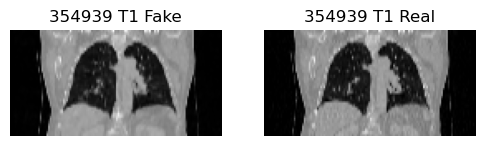

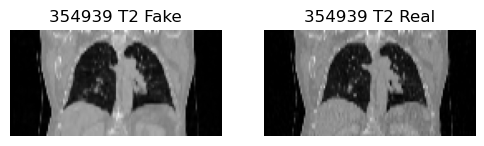

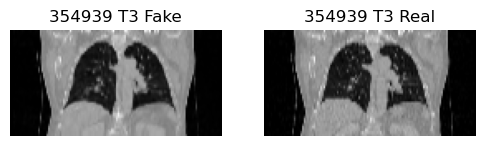

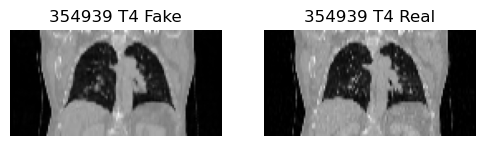

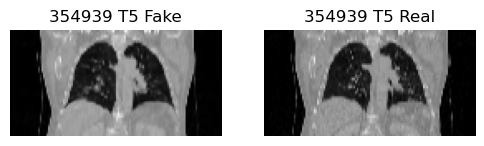

FileNotFoundError: [Errno 2] No such file or directory: '/home/zhaosheng/paper4/npy/100_354939_t6.npy'

In [15]:


import numpy as np
import matplotlib.pyplot as plt


epoch = 100
pid = 354939
# t_index = 5
for t_index in range(1,10):
    fake = np.load(f"/home/zhaosheng/paper4/npy/{epoch}_{pid}_t{t_index}.npy")
    real = np.load(f"/home/zhaosheng/paper4/npy/{epoch}_{pid}_t{t_index}_real.npy")
    plt.figure(dpi=100)
    plt.subplot(1,2,1)
    plt.imshow(fake[50,:,::-1].transpose(1,0),cmap='gray')
    plt.title(f"{pid} T{t_index} Fake")
    plt.axis("off")
    plt.subplot(1,2,2)
    plt.imshow(real[50,:,::-1].transpose(1,0),cmap='gray')
    plt.title(f"{pid} T{t_index} Real")
    plt.axis("off")
    plt.show()

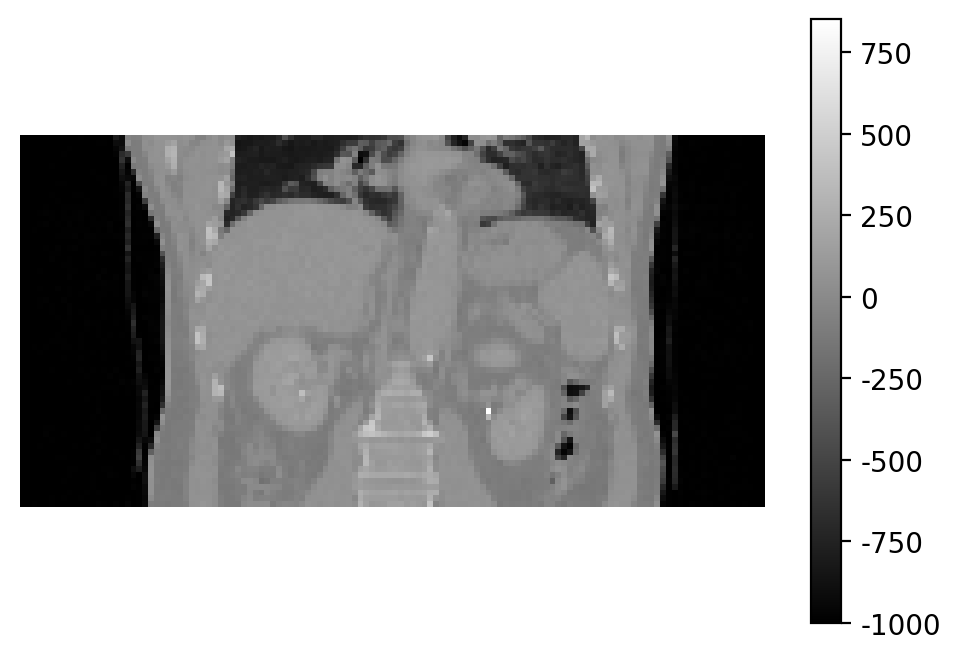

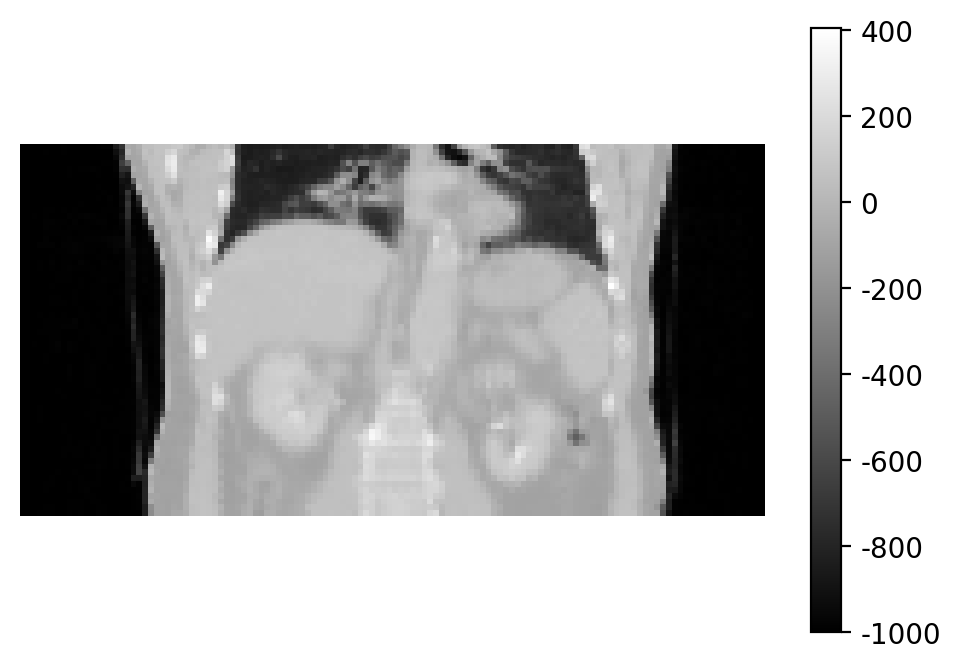

In [10]:


# plt.figure(dpi=200)
# plt.imshow(t0[55,:,::-1].transpose(1,0),cmap='gray')
# plt.axis("off")
# plt.savefig("t0.png")

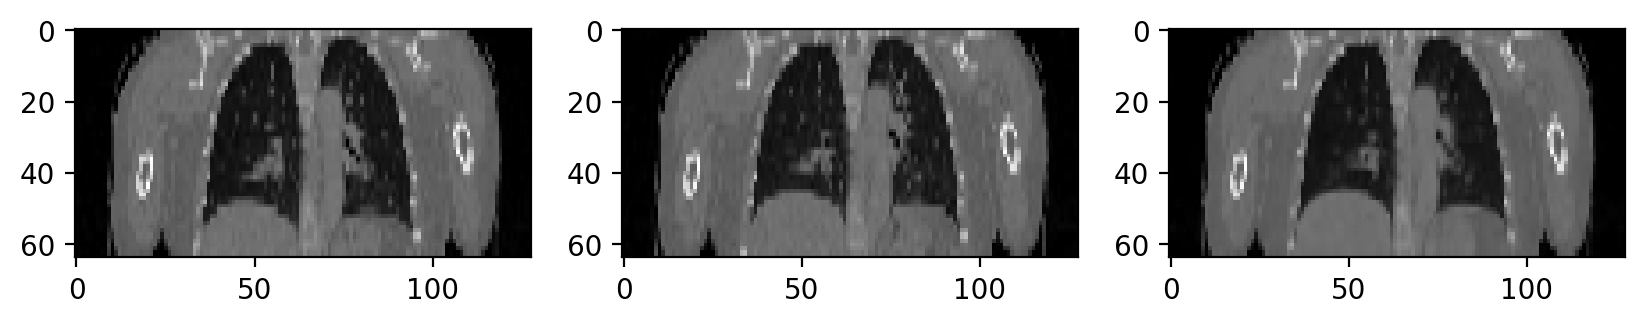

In [3]:
import numpy as np
import matplotlib.pyplot as plt
plt.figure(figsize=(10,3),dpi=200)
ax1 = plt.subplot(1,3,1)
a = np.load("./npy/A2B_0425_resize_flipd/140_hanjianying_t1_real.npy")
ax1.imshow(a.transpose(2,0,1)[::-1,64,:],cmap='gray')

ax2 = plt.subplot(1,3,2)

a = np.load("./npy/A2B_0425_resize_flipd/140_hanjianying_t5_real.npy")
ax2.imshow(a.transpose(2,0,1)[::-1,64,:],cmap='gray')

ax3 = plt.subplot(1,3,3)

a = np.load("./npy/A2B_0425_resize_flipd/140_hanjianying_t5.npy")
ax3.imshow(a.transpose(2,0,1)[::-1,64,:],cmap='gray')
plt.show()

In [ ]:
from monai.networks.blocks import Warp
import torch
import ants
import os
import antspynet
import numpy as np

def plot_ct(img,slices):
    img2 = img-img.min()
    img2.plot(axis=1,slices=slices)

def compute_area(mask, pixdim):
    """
    Computes the area (number of pixels) of a binary mask and multiplies the pixels
    with the pixel dimension of the acquired CT image
    Args:
        lung_mask: binary lung mask
        pixdim: list or tuple with two values
    Returns: the lung area in mm^2
    """
    mask[mask >= 1] = 1
    lung_pixels = np.sum(mask)
    return lung_pixels * pixdim[0] * pixdim[1]* pixdim[2]

def resample_dff(ddf_npy_filepath,moving_filepath,fixed_filepath,warp,savepath=None,get_lung=False):
    moving_img = ants.image_read(moving_filepath)
    fixed_img = ants.image_read(fixed_filepath)
    
    ddf = []
    for index in range(3):
        ddf_npy = np.load(ddf_npy_filepath)[0,index]
        ddf_raw = ants.from_numpy(ddf_npy)
        ddf_raw = ants.resample_image(ddf_raw,moving_img.shape,True,4)
        ddf.append(ddf_raw.numpy())
    ddf = torch.tensor(np.array(ddf))

    img = torch.tensor(moving_img.numpy())

    img = torch.unsqueeze(img, dim=0)
    img = torch.unsqueeze(img, dim=0)
    img = (img+1000.)/3000.
    img[img<0]=0
    img[img>1]=1
    
    ddf = torch.unsqueeze(ddf, dim=0)
    output_img = warp(img,ddf).numpy()
    print(f"\tIMG shape:{img.shape}")
    print(f"\tDDF shape:{ddf.shape}")
    print(f"\tOUT shape:{output_img.shape}")
    output_img = ants.from_numpy(output_img[0,0,:,:,:])
    output_img.set_spacing(moving_img.spacing)
    # print(moving_img.shape[-1])
    slices = np.linspace((moving_img.shape[1])/4,(moving_img.shape[1])/2.,9,dtype=int)
    print(slices)
    plot_ct(moving_img,slices)
    plot_ct(fixed_img,slices)
    plot_ct(output_img,slices)
    
    if savepath:
        input_filename = moving_filepath.split("/")[-1]
        real_filename = fixed_filepath.split("/")[-1]
        output_filename = ddf_npy_filepath.split("/")[-1].split(".")[0]+".nii"
        os.makedirs(os.path.join(savepath,"fake"),exist_ok=True)
        os.makedirs(os.path.join(savepath,"real"),exist_ok=True)
        os.makedirs(os.path.join(savepath,"input"),exist_ok=True)
        ants.image_write(output_img,os.path.join(savepath,"fake",output_filename))
        ants.image_write(fixed_img,os.path.join(savepath,"real",real_filename))
        ants.image_write(moving_img,os.path.join(savepath,"input",input_filename))
    if get_lung:
        real_lung_result = antspynet.utilities.lung_extraction(fixed_img, modality='ct', verbose=True)
        fake_lung_result = antspynet.utilities.lung_extraction(output_filename, modality='ct', verbose=True)
        real_left_Lung = real_lung_result['probability_images'][1]
        real_right_Lung = real_lung_result['probability_images'][2]
        fake_left_Lung = fake_lung_result['probability_images'][1]
        fake_right_Lung = fake_lung_result['probability_images'][2]
        fake_left_area = compute_area(fake_left_Lung,output_filename.spacing)
        # left_Lung[left_Lung>=0.5]=1
        # left_Lung[left_Lung<0.5]=0
        print(fake_left_area)


    return ddf,moving_img,fixed_img,output_img



In [ ]:
warp = Warp()
ddf,moving_img,fixed_img,output_img = resample_dff("/home/zhaosheng/paper4/outputs/B2A_0425_resize_flipd/ddfs/159_caowujun_ddf5_fake.npy",
                                 "/zhaosheng_data/4dct_2_test/caowujun/caowujun_t0.nii",
                                 "/zhaosheng_data/4dct_2_test/caowujun/caowujun_t5.nii",
                                 warp,"./results",get_lung=True)

In [1]:
from monai.networks.blocks import Warp
import torch
import ants
import os
import numpy as np

def plot_ct(img,slices):
    img2 = img-img.min()
    img2.plot(axis=1,slices=slices)

def compute_area(mask, pixdim):
    """
    Computes the area (number of pixels) of a binary mask and multiplies the pixels
    with the pixel dimension of the acquired CT image
    Args:
        lung_mask: binary lung mask
        pixdim: list or tuple with two values
    Returns: the lung area in mm^2
    """
    mask[mask >= 1] = 1
    lung_pixels = np.sum(mask)
    return lung_pixels * pixdim[0] * pixdim[1]* pixdim[2]

def resample_dff(ddf_npy_filepath,moving_filepath,fixed_filepath,warp,savepath=None):
    moving_img = ants.image_read(moving_filepath)
    fixed_img = ants.image_read(fixed_filepath)
    ddf = []
    for index in range(3):
        ddf_npy = np.load(ddf_npy_filepath)[0,index]
        ddf_raw = ants.from_numpy(ddf_npy)
        ddf_raw = ants.resample_image(ddf_raw,moving_img.shape,True,4)
        ddf.append(ddf_raw.numpy())
    ddf = torch.tensor(np.array(ddf))

    img = torch.tensor(moving_img.numpy())

    img = torch.unsqueeze(img, dim=0)
    img = torch.unsqueeze(img, dim=0)
    img = (img+1000.)/3000.
    img[img<0]=0
    img[img>1]=1
    
    ddf = torch.unsqueeze(ddf, dim=0)
    output_img = warp(img,ddf).numpy()
    print(f"\tIMG shape:{img.shape}")
    print(f"\tDDF shape:{ddf.shape}")
    print(f"\tOUT shape:{output_img.shape}")
    output_img = ants.from_numpy(output_img[0,0,:,:,:])
    output_img.set_spacing(moving_img.spacing)
    # print(moving_img.shape[-1])
    slices = np.linspace((moving_img.shape[1])/4,(moving_img.shape[1])/2.,9,dtype=int)
    print(slices)
    plot_ct(moving_img,slices)
    plot_ct(fixed_img,slices)
    plot_ct(output_img,slices)
    
    if savepath:
        input_filename = moving_filepath.split("/")[-1]
        real_filename = fixed_filepath.split("/")[-1]
        output_filename = ddf_npy_filepath.split("/")[-1].split(".")[0]+".nii"
        os.makedirs(os.path.join(savepath,"fake"),exist_ok=True)
        os.makedirs(os.path.join(savepath,"real"),exist_ok=True)
        os.makedirs(os.path.join(savepath,"input"),exist_ok=True)
        ants.image_write(output_img,os.path.join(savepath,"fake",output_filename))
        ants.image_write(fixed_img,os.path.join(savepath,"real",real_filename))
        ants.image_write(moving_img,os.path.join(savepath,"input",input_filename))
    return ddf,moving_img,fixed_img,output_img



In [ ]:
warp = Warp()
ddf,moving_img,fixed_img,output_img = resample_dff("/home/zhaosheng/paper4/outputs/B2A_0425_resize_flipd/ddfs/159_caowujun_ddf5_fake.npy",
                                 "/zhaosheng_data/4dct_2_test/caowujun/caowujun_t0.nii",
                                 "/zhaosheng_data/4dct_2_test/caowujun/caowujun_t5.nii",
                                 warp,savepath=None)

In [4]:
from antspynet.utilities import lung_extraction
from monai.networks.blocks import Warp
import torch
import ants
import os
# from get_lung_volume import get_lung_mask
import numpy as np

In [19]:

def plot_ct(img,slices):
    img2 = img-img.min()
    img2.plot(axis=1,slices=slices)

def compute_volume(img):
    """
    Computes the area (number of pixels) of a binary mask and multiplies the pixels
    with the pixel dimension of the acquired CT image
    Args:
        lung_mask: binary lung mask
        pixdim: list or tuple with two values
    Returns: the lung area in mm^2
    """
    pixdim = img.spacing
    img = img.numpy()
    # img[img >= 0.5] = 1
    # img[img < 0.5] = 0
    lung_pixels = np.sum(img)
    return lung_pixels * pixdim[0] * pixdim[1]* pixdim[2]

def get_lung_mask(img):
    lung_result = lung_extraction(img, modality='ct', verbose=False)
    left_lung = lung_result['probability_images'][1]
    right_lung = lung_result['probability_images'][2]

    left_lung_volume = compute_volume(left_lung)
    right_lung_volume = compute_volume(right_lung)

    return {"left_lung_volume":left_lung_volume,
            "right_lung_volume":right_lung_volume,
            "left_lung":left_lung,
            "right_lung":right_lung}

def resample_dff(ddf_npy_filepath,moving_filepath,fixed_filepath,warp,savepath=None):
    moving_img = ants.image_read(moving_filepath)
    fixed_img = ants.image_read(fixed_filepath)
    ddf = []
    for index in range(3):
        ddf_npy = np.load(ddf_npy_filepath)[0,index]
        ddf_raw = ants.from_numpy(ddf_npy)
        ddf_raw = ants.resample_image(ddf_raw,moving_img.shape,True,1)
        ddf.append(ddf_raw.numpy())
    ddf = torch.tensor(np.array(ddf))

    img = torch.tensor(moving_img.numpy())

    img = torch.unsqueeze(img, dim=0)
    img = torch.unsqueeze(img, dim=0)
    img = (img+1000.)/3000.
    img[img<0]=0
    img[img>1]=1
    
    ddf = torch.unsqueeze(ddf, dim=0)
    output_img = warp(img,ddf).numpy()
    print(f"\tIMG shape:{img.shape}")
    print(f"\tDDF shape:{ddf.shape}")
    print(f"\tOUT shape:{output_img.shape}")
    output_img = ants.from_numpy(output_img[0,0,:,:,:])
    output_img.set_spacing(moving_img.spacing)
    # print(moving_img.shape[-1])
    slices = np.linspace((moving_img.shape[1])/4,(moving_img.shape[1])/2.,9,dtype=int)
    # print(slices)
    plot_ct(moving_img,slices)
    plot_ct(fixed_img,slices)
    plot_ct(output_img,slices)
    
    if savepath:
        input_filename = moving_filepath.split("/")[-1]
        real_filename = fixed_filepath.split("/")[-1]
        output_filename = ddf_npy_filepath.split("/")[-1].split(".")[0]+".nii"
        os.makedirs(os.path.join(savepath,"fake"),exist_ok=True)
        os.makedirs(os.path.join(savepath,"real"),exist_ok=True)
        os.makedirs(os.path.join(savepath,"input"),exist_ok=True)
        ants.image_write(output_img,os.path.join(savepath,"fake",output_filename))
        ants.image_write(fixed_img,os.path.join(savepath,"real",real_filename))
        ants.image_write(moving_img,os.path.join(savepath,"input",input_filename))
   

    return ddf,moving_img,fixed_img,output_img


`should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.


In [20]:
import os
ddf_path = "/home/zhaosheng/paper4/outputs/A2B_0425_resize_flipd/ddfs"
epoch = "159"


files = sorted([os.path.join(ddf_path,file) for file in os.listdir(ddf_path) if ".npy" in file])

pnames = set([file.split("/")[-1].split("_")[1] for file in files])
print(pnames)
for pname in pnames:
    patient_files = sorted([file for file in files if pname in file and epoch+"_" in file])
    print(patient_files)
    # real_t0 = f"/zhaosheng_data/4dct_2_test/{pname}/{pname}_t0.nii"
    # real_t1 = f"/zhaosheng_data/4dct_2_test/{pname}/{pname}_t1.nii"
    # real_t2 = f"/zhaosheng_data/4dct_2_test/{pname}/{pname}_t2.nii"
    # real_t3 = f"/zhaosheng_data/4dct_2_test/{pname}/{pname}_t3.nii"
    # real_t4 = f"/zhaosheng_data/4dct_2_test/{pname}/{pname}_t4.nii"
    # real_t5 = f"/zhaosheng_data/4dct_2_test/{pname}/{pname}_t5.nii"

{'lubaimei', 'chenxiaosi', 'chenjinsheng', 'huzhiwen', 'jinyurong', 'licuihua', 'guixiufang', 'huyannian', 'yueshuqing', 'chenguangdeng', 'jimeihong', 'liyifeng2', 'caowujun', 'pengmeidi', 'hexiaochun', 'lvqingcheng', 'liuwansheng', 'hanjianying'}
['/home/zhaosheng/paper4/outputs/A2B_0425_resize_flipd/ddfs/159_lubaimei_ddf1_fake.npy', '/home/zhaosheng/paper4/outputs/A2B_0425_resize_flipd/ddfs/159_lubaimei_ddf2_fake.npy', '/home/zhaosheng/paper4/outputs/A2B_0425_resize_flipd/ddfs/159_lubaimei_ddf3_fake.npy', '/home/zhaosheng/paper4/outputs/A2B_0425_resize_flipd/ddfs/159_lubaimei_ddf4_fake.npy', '/home/zhaosheng/paper4/outputs/A2B_0425_resize_flipd/ddfs/159_lubaimei_ddf5_fake.npy']
['/home/zhaosheng/paper4/outputs/A2B_0425_resize_flipd/ddfs/159_chenxiaosi_ddf1_fake.npy', '/home/zhaosheng/paper4/outputs/A2B_0425_resize_flipd/ddfs/159_chenxiaosi_ddf2_fake.npy', '/home/zhaosheng/paper4/outputs/A2B_0425_resize_flipd/ddfs/159_chenxiaosi_ddf3_fake.npy', '/home/zhaosheng/paper4/outputs/A2B_0425

monai.networks.blocks.Warp: Using PyTorch native grid_sample.


	IMG shape:torch.Size([1, 1, 512, 512, 109])
	DDF shape:torch.Size([1, 3, 512, 512, 109])
	OUT shape:(1, 1, 512, 512, 109)


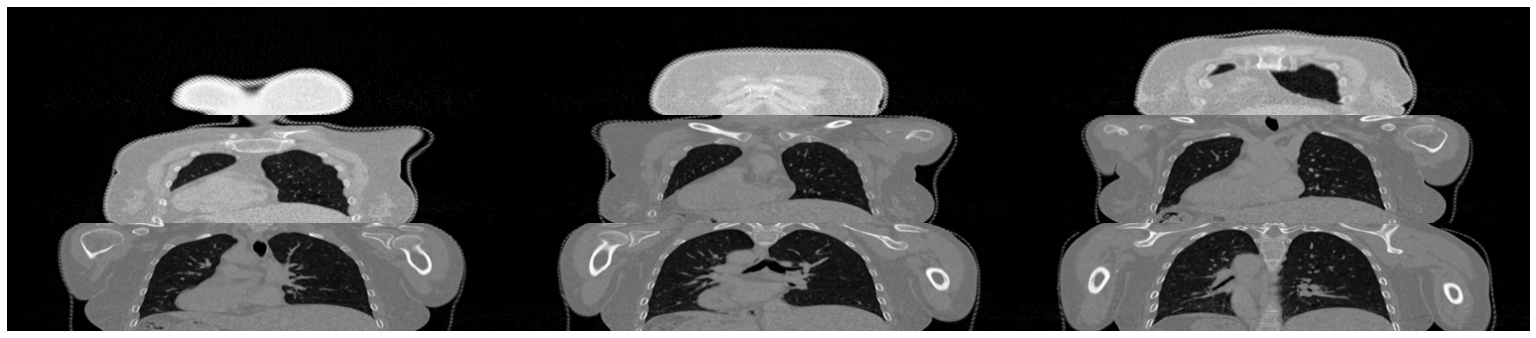

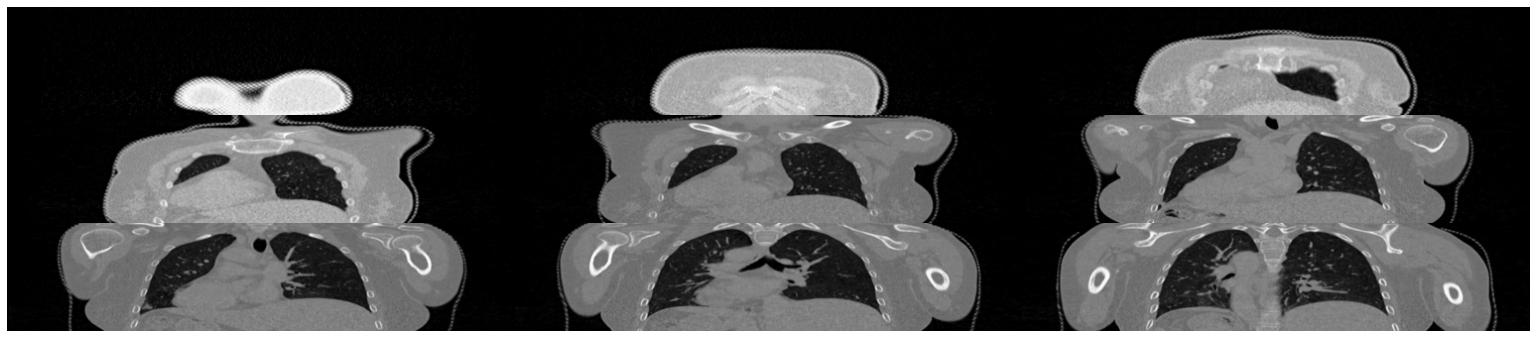

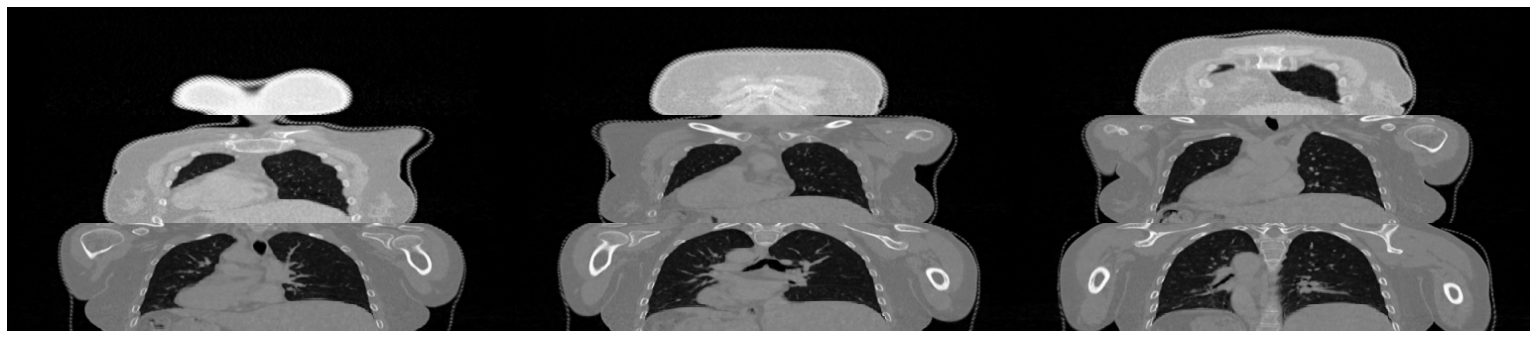

832541.7637825012
1454116.5828704834
643000.0066757202
1279746.7708587646
769609.6897125244
1221132.8744888306
Error:
	Left Lung:-16.45%
	Right Lung:4.80%


In [21]:
warp = Warp()
ddf,moving_img,fixed_img,output_img = resample_dff("/home/zhaosheng/paper4/outputs/A2B_0425_resize_flipd/ddfs/159_hanjianying_ddf5_fake.npy",
                                "/home/zhaosheng/4dct_test_nii/hanjianying/hanjianying_t0.nii",
                                "/home/zhaosheng/4dct_test_nii/hanjianying/hanjianying_t5.nii",
                                warp,"./results")
input_result = get_lung_mask(moving_img)
print(input_result["left_lung_volume"])
print(input_result["right_lung_volume"])

fake_result = get_lung_mask(output_img)
print(fake_result["left_lung_volume"])
print(fake_result["right_lung_volume"])

real_result = get_lung_mask(fixed_img)
print(real_result["left_lung_volume"])
print(real_result["right_lung_volume"])
left_err = (fake_result["left_lung_volume"] - real_result["left_lung_volume"])/real_result["left_lung_volume"] * 100.
right_err = (fake_result["right_lung_volume"] - real_result["right_lung_volume"])/real_result["right_lung_volume"] * 100.
print(f"Error:\n\tLeft Lung:{left_err:.2f}%\n\tRight Lung:{right_err:.2f}%")